# Veri Ön İşleme: Scaler Yöntemleri

## Scaler Nedir?

Scaler, **makine öğrenmesi modellerini eğitmeden önce özellik (feature) değerlerini bir standart aralığa dönüştüren** ön işleme tekniğidir. Farklı ölçeklerdeki özellikleri genellikle 0-1 aralığına veya sıfır ortalama ile normalize ederek, modelin daha hızlı ve etkili şekilde öğrenmesini sağlar.

### Neden Gerekli?

Finansal veriler (hisse senedi fiyatları, volatilite, RSI endeksi) genellikle farklı birimler ve aralıklarda olur. Örneğin:
- **RSI:** 0-100 arası
- **Volatilite:** 0.01-0.05 arası  
- **Fiyat:** 1000-100000 arası

Bu ölçek farklarını normalize etmezseniz, model yüksek değerlere daha fazla ağırlık verir ve eğitim verimsiz hale gelir.

In [30]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from dataclasses import dataclass
from enum import Enum
from typing import Optional, Union, List, Tuple

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression

In [31]:
class ScalerType(Enum):
    STANDARD = 'standard'
    MINMAX = 'minmax'
    ROBUST = 'robust'

## Scaler Türleri ve Karşılaştırması

| Scaler | Çalışma Mantığı | Ne Zaman Kullanılır? | Finansal Veri Notu |
|--------|-----------------|----------------------|-------------------|
| **StandardScaler** | Veriyi 0 ortalama ve 1 standart sapma haline getirir | Veri normal dağılıyorsa (Gaussian) en iyisidir | Aykırı değerler (iğneler) ortalamayı bozabilir |
| **MinMaxScaler** | Veriyi belirlenen bir aralığa (genelde 0-1) sıkıştırır | Derin öğrenme ve görüntü işlemede çok popülerdir | Uç bir değer varsa, diğer tüm veriler birbirine çok yakınlaşır |
| **RobustScaler** | Medyanı ve IQR (Interquartile Range) değerini kullanır | Aykırı değerlerin (Outliers) bol olduğu durumlarda | Kripto gibi volatil piyasalar için en güvenlisidir |

### Matematiksel Tanımlar

**StandardScaler:**
$$z = \frac{x - \mu}{\sigma}$$

**MinMaxScaler:**
$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$

**RobustScaler:**
$$x' = \frac{x - \text{median}}{IQR}$$
Burada IQR = Q₃ - Q₁

In [32]:
@dataclass

class PreprocessingConfig:
    scaler_type : ScalerType
    features: List[str]
    target: str
    test_size : float = 0.2
    random_state : int = 42

### PreprocessingConfig

Veri işleme parametrelerini merkezileştirmiş bir configuration sınıfı. Hangi scaler kullanılacağı, hangi özelliklerin seçileceği ve test/train bölünme oranı burada tanımlanır.

## Mimari Tasarım

Bu projede, veri ön işlemesi için bir Factory deseni kullanılmıştır. Bu sayede farklı scaler türleri kolaylıkla değiştirilebilir.

In [33]:
class ScalerFactory:
    @staticmethod
    def get_scaler(scaler_type: ScalerType):
        if scaler_type == ScalerType.STANDARD:
            return StandardScaler()
        elif scaler_type == ScalerType.MINMAX:
            return MinMaxScaler()
        elif scaler_type == ScalerType.ROBUST:
            return RobustScaler()
        else:
            raise ValueError(f"Unsupported scaler type: {scaler_type}")

### ScalerFactory

**Factory Design Pattern** kullanarak, istenen scaler türüne göre uygun nesneyi oluşturur. Bu deseni kullanmak, kodun esnekliğini ve bakım edilebilirliğini artırır.

In [34]:
def create_synthetic_data(n: int = 1000):
    np.random.seed(42)

    rsi = np.random.uniform(0, 100, n)
    volatility = np.random.uniform(0.01, 0.05, n)
    noise = np.random.normal(0, 1, n)

    target = 0.7 * rsi + 100 * volatility + np.random.normal(0, 5, n)

    return pd.DataFrame({
        'rsi' : rsi,
        'volatility' : volatility, 
        'noise_column' : noise,
        'target' : target
    })

### Sentetik Veri Oluşturma

Bu fonksiyon, finansal piyasalarda yaygın gözlenen özellikleri simüle eder:
- **RSI (Relative Strength Index):** 0-100 arasında momentum göstergesi
- **Volatilite:** Fiyat dalgalanmasının ölçüsü
- **Gürültü (Noise):** Piyasadaki anomalileri temsil eder

In [35]:
class Processor:
    def __init__(self, ctx: PreprocessingConfig):
        self.ctx = ctx
        self.scaler = ScalerFactory.get_scaler(ctx.scaler_type)

    def process(self, df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        X = df[self.ctx.features].values
        y = df[self.ctx.target].values

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=self.ctx.test_size, random_state=self.ctx.random_state
        )

        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        return X_train_scaled, X_test_scaled, y_train, y_test

### Processor Sınıfı

Veriyi işleyen ana sınıf. Şunları yapar:
1. Belirlenen özellikleri dataframe'den çıkarır
2. Train/Test setine böler
3. Seçilen scaler'ı train setine fit eder
4. Hem train hem test setini transform eder

Bu yapı, scaler'ın sadece train setine fit edilmesini sağlayarak, veri sızıntısını (data leakage) önler.

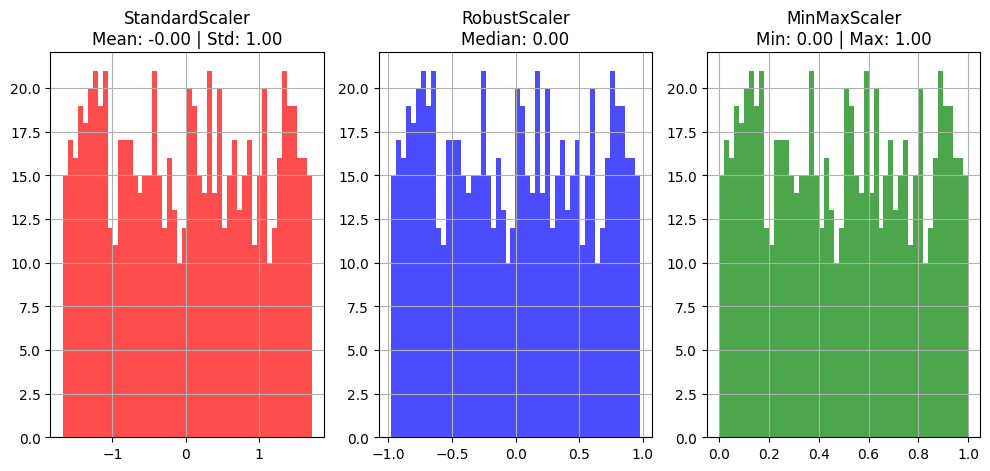

In [ ]:
config_std = PreprocessingConfig(
    scaler_type=ScalerType.STANDARD,
    features=['rsi', 'volatility', 'noise_column'],
    target='target'
)
config_rob = PreprocessingConfig(
    scaler_type=ScalerType.ROBUST,
    features=['rsi', 'volatility', 'noise_column'],
    target='target'
)
config_minmax = PreprocessingConfig(
    scaler_type=ScalerType.MINMAX,
    features=['rsi', 'volatility', 'noise_column'],
    target='target'
)

processor_std = Processor(config_std)
X_train_std, X_test_std, _, _ = processor_std.process(df)

processor_rob = Processor(config_rob)
X_train_rob, X_test_rob, _, _ = processor_rob.process(df)

processor_minmax = Processor(config_minmax)
X_train_minmax, X_test_minmax, _, _ = processor_minmax.process(df)
 
X_train_std_flat = X_train_std[:, 0]
X_train_rob_flat = X_train_rob[:, 0]
X_train_minmax_flat = X_train_minmax[:, 0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.hist(X_train_std_flat, bins=50, color='red', alpha=0.7)
plt.title(f"StandardScaler\nMean: {X_train_std_flat.mean():.2f} | Std: {X_train_std_flat.std():.2f}")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.hist(X_train_rob_flat, bins=50, color='blue', alpha=0.7)
plt.title(f"RobustScaler\nMedian: {np.median(X_train_rob_flat):.2f}")
plt.grid(True)  

plt.subplot(1, 3, 3)
plt.hist(X_train_minmax_flat, bins=50, color='green', alpha=0.7)
plt.title(f"MinMaxScaler\nMin: {X_train_minmax_flat.min():.2f} | Max: {X_train_minmax_flat.max():.2f}")
plt.grid(True)

plt.show()

## Scaler'ların Uygulanması ve Karşılaştırması

Aşağıdaki kodda, aynı veri seti üzerinde üç farklı scaler yöntemi uygulanır ve sonuçları görselleştirilir. Her scaler'ın dağılıma nasıl etki ettiğini gözlemleyebilirsiniz.

In [ ]:
def check_importance(X, y, feature_names):
   
    mi_scores = mutual_info_regression(X, y)
    mi_results = pd.Series(mi_scores, name="MI Scores", index=feature_names)
    return mi_results.sort_values(ascending=False)

## Feature Importance Analizi

**Mutual Information (MI)** kullanarak, her özelliğin hedef değişken ile ne kadar ilişkili olduğunu ölçeriz. Doğrusal olmayan ilişkileri de yakalayan bu yöntem, finansal verilerde özellikle etkilidir.

In [ ]:
df = create_synthetic_data()
context = PreprocessingConfig(
    scaler_type=ScalerType.ROBUST,
    features=['rsi', 'volatility', 'noise_column'],
    target='target'
)

processor = Processor(context)
X_train_s, X_test_s, y_train, y_test = processor.process(df)
 
importance = check_importance(X_train_s, y_train, context.features)
print("Özellik Önem Sıralaması (Mutual Information):")
print(importance)

Özellik Önem Sıralaması (Mutual Information):
rsi             1.321041
volatility      0.017043
noise_column    0.006029
Name: MI Scores, dtype: float64


## Sonuç

Bu analiz sonucunda:
- **RSI**, hedef değişkenle en güçlü ilişkiye sahiptir (MI: ~1.32)
- **Volatilite**, orta düzeyde bir etkiye sahiptir
- **Gürültü**, neredeyse hiçbir etkiye sahip değildir

Scaler seçimi modelin türüne bağlıdır:
- Linear modeller için **StandardScaler** yeterlidir
- Derin öğrenme için **MinMaxScaler** idealdir  
- Finansal veriler için **RobustScaler** en güvenli seçimdir